# Import libraries

In [52]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Loading Data

In [53]:
#loading data 
df = pd.read_csv("Womens Clothing E-Commerce Reviews.csv")
df.head()

,Unnamed: 0,Clothing ID,Age,Title,Review Text,Rating,Recommended IND,Positive Feedback Count,Division Name,Department Name,Class Name
0,0,767,33,NaN,Absolutely wonderful - silky and sexy and comf...,4,1,0,Initmates,Intimate,Intimates
1,1,1080,34,NaN,Love this dress! it's sooo pretty. i happene...,5,1,4,General,Dresses,Dresses
2,2,1077,60,Some major design flaws,I had such high hopes for this dress and reall...,3,0,0,General,Dresses,Dresses
3,3,1049,50,My favorite buy!,"I love, love, love this jumpsuit. it's fun, fl...",5,1,0,General Petite,Bottoms,Pants
4,4,847,47,Flattering shirt,This shirt is very flattering to all due to th...,5,1,6,General,Tops,Blouses


# EDA and Data Cleaning

In [54]:
df.columns

Index(['Unnamed: 0', 'Clothing ID', 'Age', 'Title', 'Review Text', 'Rating',
       'Recommended IND', 'Positive Feedback Count', 'Division Name',
       'Department Name', 'Class Name'],
      dtype='object')

In [55]:
df.shape

(23486, 11)

In [56]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23486 entries, 0 to 23485
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   Unnamed: 0               23486 non-null  int64 
 1   Clothing ID              23486 non-null  int64 
 2   Age                      23486 non-null  int64 
 3   Title                    19676 non-null  object
 4   Review Text              22641 non-null  object
 5   Rating                   23486 non-null  int64 
 6   Recommended IND          23486 non-null  int64 
 7   Positive Feedback Count  23486 non-null  int64 
 8   Division Name            23472 non-null  object
 9   Department Name          23472 non-null  object
 10  Class Name               23472 non-null  object
dtypes: int64(6), object(5)
memory usage: 2.0+ MB


In [57]:
df.describe()

,Unnamed: 0,Clothing ID,Age,Rating,Recommended IND,Positive Feedback Count
count,23486.000000,23486.000000,23486.000000,23486.000000,23486.000000,23486.000000
mean,11742.500000,918.118709,43.198544,4.196032,0.822362,2.535936
std,6779.968547,203.298980,12.279544,1.110031,0.382216,5.702202
min,0.000000,0.000000,18.000000,1.000000,0.000000,0.000000
25%,5871.250000,861.000000,34.000000,4.000000,1.000000,0.000000
50%,11742.500000,936.000000,41.000000,5.000000,1.000000,1.000000
75%,17613.750000,1078.000000,52.000000,5.000000,1.000000,3.000000
max,23485.000000,1205.000000,99.000000,5.000000,1.000000,122.000000


In [58]:
#removing the unnnecessary columsn
df = df.drop(columns=['Unnamed: 0','Clothing ID', 'Age', 'Title', 'Positive Feedback Count', 'Division Name', 'Class Name'])

In [59]:
df.head()

,Review Text,Rating,Recommended IND,Department Name
0,Absolutely wonderful - silky and sexy and comf...,4,1,Intimate
1,Love this dress! it's sooo pretty. i happene...,5,1,Dresses
2,I had such high hopes for this dress and reall...,3,0,Dresses
3,"I love, love, love this jumpsuit. it's fun, fl...",5,1,Bottoms
4,This shirt is very flattering to all due to th...,5,1,Tops


In [60]:
#checking null values
df.isnull().sum()

Review Text        845
Rating               0
Recommended IND      0
Department Name     14
dtype: int64

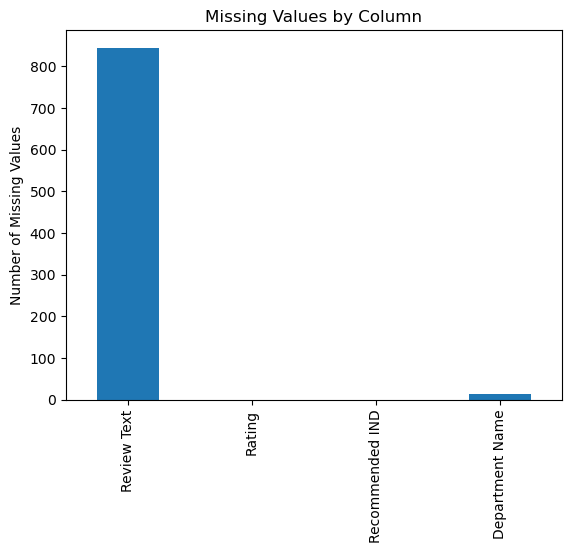

In [61]:
df.isnull().sum().plot(kind='bar')

plt.title("Missing Values by Column")
plt.ylabel("Number of Missing Values")
plt.show()

In [62]:
df.columns

Index(['Review Text', 'Rating', 'Recommended IND', 'Department Name'], dtype='object')

In [63]:
df.head()

,Review Text,Rating,Recommended IND,Department Name
0,Absolutely wonderful - silky and sexy and comf...,4,1,Intimate
1,Love this dress! it's sooo pretty. i happene...,5,1,Dresses
2,I had such high hopes for this dress and reall...,3,0,Dresses
3,"I love, love, love this jumpsuit. it's fun, fl...",5,1,Bottoms
4,This shirt is very flattering to all due to th...,5,1,Tops


In [64]:
df.sort_values(by='Rating')

,Review Text,Rating,Recommended IND,Department Name
20289,I purchased these in january and today i am go...,1,0,Bottoms
14201,"This coat is awful, just awful. i bought it ba...",1,0,Jackets
22346,I followed the other reviews and sized down. n...,1,0,Bottoms
23019,This skirt is definitely not what i was expect...,1,0,Bottoms
18740,"Quality was not what you expect from retailer,...",1,0,Dresses
...,...,...,...,...
10078,"This is the perfect tank. it's super soft, gre...",5,1,Intimate
10079,These tanks are very soft. i have two black an...,5,1,Intimate
10080,Love the cut of this t-shirt. just loose enoug...,5,1,Tops
10082,"But when i saw this top in person, urged by my...",5,1,Tops


In [65]:
#dropping empty review text values
df = df.dropna(subset=['Review Text'])

In [66]:
df.columns

Index(['Review Text', 'Rating', 'Recommended IND', 'Department Name'], dtype='object')

In [67]:
df.shape

(22641, 4)

In [68]:
df = df.dropna(subset=['Department Name'])

In [69]:
df.head()

,Review Text,Rating,Recommended IND,Department Name
0,Absolutely wonderful - silky and sexy and comf...,4,1,Intimate
1,Love this dress! it's sooo pretty. i happene...,5,1,Dresses
2,I had such high hopes for this dress and reall...,3,0,Dresses
3,"I love, love, love this jumpsuit. it's fun, fl...",5,1,Bottoms
4,This shirt is very flattering to all due to th...,5,1,Tops


# Creating Traget Label

In [70]:
def to_sentiment(r):
    return 'Positive' if r >= 4 else 'Not Positive'

df['Sentiment'] = df['Rating'].apply(to_sentiment)

In [71]:
df.head()

,Review Text,Rating,Recommended IND,Department Name,Sentiment
0,Absolutely wonderful - silky and sexy and comf...,4,1,Intimate,Positive
1,Love this dress! it's sooo pretty. i happene...,5,1,Dresses,Positive
2,I had such high hopes for this dress and reall...,3,0,Dresses,Not Positive
3,"I love, love, love this jumpsuit. it's fun, fl...",5,1,Bottoms,Positive
4,This shirt is very flattering to all due to th...,5,1,Tops,Positive


In [72]:
df.duplicated().sum()

np.int64(6)

In [73]:
df[df.duplicated()]

,Review Text,Rating,Recommended IND,Department Name,Sentiment
10067,Perfect fit and i've gotten so many compliment...,5,1,Intimate,Positive
11074,"Lightweight, soft cotton top and shorts. i thi...",5,1,Intimate,Positive
12526,I purchased this and another eva franco dress ...,2,0,Dresses,Not Positive
13354,Perfect fit and i've gotten so many compliment...,5,1,Intimate,Positive
14275,I bought this shirt at the store and after goi...,5,1,Tops,Positive
21888,"Love, love these jeans. being short they come ...",5,1,Bottoms,Positive


In [74]:
df = df.drop_duplicates()

In [75]:
df.head()

,Review Text,Rating,Recommended IND,Department Name,Sentiment
0,Absolutely wonderful - silky and sexy and comf...,4,1,Intimate,Positive
1,Love this dress! it's sooo pretty. i happene...,5,1,Dresses,Positive
2,I had such high hopes for this dress and reall...,3,0,Dresses,Not Positive
3,"I love, love, love this jumpsuit. it's fun, fl...",5,1,Bottoms,Positive
4,This shirt is very flattering to all due to th...,5,1,Tops,Positive


In [76]:
df.shape

(22622, 5)

In [77]:
#removing extar spaces from start and end
df['Review Text']=df['Review Text'].str.strip()
df['Department Name']=df['Department Name'].str.strip()
df['Sentiment']=df['Sentiment'].str.strip()

In [78]:
# Review length outliers
lengths = df['Review Text'].str.split().str.len()
print(lengths.describe())

count    22622.000000
mean        60.213421
std         28.531453
min          2.000000
25%         36.000000
50%         59.000000
75%         88.000000
max        115.000000
Name: Review Text, dtype: float64


In [79]:
#outlier check
print(df['Rating'].unique())      
print(df['Recommended IND'].unique())

[4 5 3 2 1]
[1 0]


# Review Text Processing

In [80]:
#text processing for review text
import re

def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-z\s]', '', text)   # keep only letters + spaces
    text = re.sub(r'\s+', ' ', text).strip()  # collapse extra spaces
    return text

df['Clean Text'] = df['Review Text'].apply(clean_text)

In [81]:
df.columns

Index(['Review Text', 'Rating', 'Recommended IND', 'Department Name',
       'Sentiment', 'Clean Text'],
      dtype='object')

In [82]:
#understanding relation ship betwene features
pd.crosstab(df["Rating"], df["Sentiment"])

Sentiment,Not Positive,Positive
Rating,,
1,821,0
2,1548,0
3,2823,0
4,0,4908
5,0,12522


In [83]:

pd.crosstab(df["Department Name"], df["Sentiment"])

Sentiment,Not Positive,Positive
Department Name,,
Bottoms,724,2937
Dresses,1510,4634
Intimate,324,1326
Jackets,198,804
Tops,2396,7651
Trend,40,78


In [84]:
df[["Rating", "Recommended IND"]].corr()

,Rating,Recommended IND
Rating,1.000000,0.792495
Recommended IND,0.792495,1.000000


In [85]:
df['Department Name'] = df['Department Name'].replace('Intimate', 'Sleep Wears')

In [86]:
df.head()

,Review Text,Rating,Recommended IND,Department Name,Sentiment,Clean Text
0,Absolutely wonderful - silky and sexy and comf...,4,1,Sleep Wears,Positive,absolutely wonderful silky and sexy and comfor...
1,Love this dress! it's sooo pretty. i happene...,5,1,Dresses,Positive,love this dress its sooo pretty i happened to ...
2,I had such high hopes for this dress and reall...,3,0,Dresses,Not Positive,i had such high hopes for this dress and reall...
3,"I love, love, love this jumpsuit. it's fun, fl...",5,1,Bottoms,Positive,i love love love this jumpsuit its fun flirty ...
4,This shirt is very flattering to all due to th...,5,1,Tops,Positive,this shirt is very flattering to all due to th...


# Choosing X and y

In [87]:

X = df['Clean Text']
y = df['Sentiment']


# Spliting datasets

In [88]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


In [89]:
print(X_test.shape)

(4525,)


# TF-IDF Vectorzation

In [90]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

negations = {
    "not", "no", "nor", "never", "none", "cannot", "n't"
}
custom_stopwords = ENGLISH_STOP_WORDS - negations
vectorizer = TfidfVectorizer(max_features=10000, stop_words=list(custom_stopwords), ngram_range=(1,2))
X_train_transformed = vectorizer.fit_transform(X_train)
X_test_transformed = vectorizer.transform(X_test)

In [91]:
# print(vectorizer.vocabulary_)

In [92]:
y_train.value_counts()

Sentiment
Positive        13944
Not Positive     4153
Name: count, dtype: int64

# Train Model

In [93]:

from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000,C=0.5, class_weight='balanced')
model.fit(X_train_transformed, y_train)
#balance :using it coz otherwise the model will become biased towards positiev (13944:as its more)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,0.5
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


# Prediction

In [94]:
y_predict = model.predict(X_test_transformed)
print(y_predict)

comparison = pd.DataFrame(
    {'Actual':y_test.values,
     'Predicted':y_predict
    })
comparison.head(15)

['Positive' 'Positive' 'Not Positive' ... 'Positive' 'Not Positive'
 'Positive']


,Actual,Predicted
0,Positive,Positive
1,Positive,Positive
2,Not Positive,Not Positive
3,Positive,Positive
4,Positive,Positive
5,Not Positive,Not Positive
6,Positive,Not Positive
7,Positive,Positive
8,Positive,Positive
9,Positive,Not Positive


# Evaluation


In [95]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_predict)
print(cm)

[[ 871  168]
 [ 449 3037]]


In [96]:
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(y_test, y_predict)
print("Accuracy:", accuracy)

Accuracy: 0.8636464088397791


In [97]:
from sklearn.metrics import precision_score

precision = precision_score(
    y_test,
    y_predict,
    average=None
)

print("Precision:", precision)

Precision: [0.65984848 0.9475819 ]


In [98]:
from sklearn.metrics import recall_score

recall = recall_score(
    y_test,
    y_predict,
    average=None
)
for class_name, score in zip(model.classes_, recall):
    print(f"{class_name}: {score:.2f}")

Not Positive: 0.84
Positive: 0.87


In [99]:
from sklearn.metrics import classification_report
#model is weke at neutral and negative

print(classification_report(y_test, y_predict))

              precision    recall  f1-score   support

Not Positive       0.66      0.84      0.74      1039
    Positive       0.95      0.87      0.91      3486

    accuracy                           0.86      4525
   macro avg       0.80      0.85      0.82      4525
weighted avg       0.88      0.86      0.87      4525



# Testing

In [103]:
def predict_review(text):
    cleaned = clean_text(text)
    vectorized = vectorizer.transform([cleaned])
    prediction = model.predict(vectorized)[0]
    probabilities = model.predict_proba(vectorized)[0]

    print(f"Review: {text}")
    print(f"Predicted Sentiment: {prediction}")
    for cls, prob in zip(model.classes_, probabilities):
        print(f"  {cls}: {prob:.2%}")

# Try it
predict_review("The fabric is not soft")

Review: The fabric is not soft
Predicted Sentiment: Not Positive
  Not Positive: 77.21%
  Positive: 22.79%


In [101]:
df.head()

,Review Text,Rating,Recommended IND,Department Name,Sentiment,Clean Text
0,Absolutely wonderful - silky and sexy and comf...,4,1,Sleep Wears,Positive,absolutely wonderful silky and sexy and comfor...
1,Love this dress! it's sooo pretty. i happene...,5,1,Dresses,Positive,love this dress its sooo pretty i happened to ...
2,I had such high hopes for this dress and reall...,3,0,Dresses,Not Positive,i had such high hopes for this dress and reall...
3,"I love, love, love this jumpsuit. it's fun, fl...",5,1,Bottoms,Positive,i love love love this jumpsuit its fun flirty ...
4,This shirt is very flattering to all due to th...,5,1,Tops,Positive,this shirt is very flattering to all due to th...


In [104]:
import joblib
joblib.dump(model, "multinomial_logistic_model.pkl")
joblib.dump(vectorizer, "tfidf_vectorizer.pkl")

['tfidf_vectorizer.pkl']